# 적응형 RAG 시스템 (Adaptive RAG System)

이 노트북은 기본 RAG(Retrieval-Augmented Generation) 모델에 적응형 기능을 추가하는 방법을 구현합니다.

## 1. 환경 설정

In [275]:
# 필요한 패키지 설치
!pip install -q langchain langchain-community langchain-openai
!pip install -q chromadb
!pip install -q python-dotenv
!pip install -q langgraph
!pip install -q tavily-python
!pip install -q pypdf
!pip install -q langchain-core
!pip install -q langchain-experimental
!pip install -q pandas numpy
!pip install -q langchain-huggingface
!pip install -q langchain-elasticsearch
!pip install -q graphviz
!pip install -q langchain-teddynote

^C
Traceback (most recent call last):
  File "/Users/ijunhyeong/Desktop/IPEX_Project/myenv/bin/pip", line 5, in <module>
    from pip._internal.cli.main import main
  File "/Users/ijunhyeong/Desktop/IPEX_Project/myenv/lib/python3.11/site-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/Users/ijunhyeong/Desktop/IPEX_Project/myenv/lib/python3.11/site-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/Users/ijunhyeong/Desktop/IPEX_Project/myenv/lib/python3.11/site-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/Users/ijunhyeong/Desktop/IPEX_Project/myenv/lib/python3.11/site-packages/pip/_internal/build_env.py", line 17, in <module>
    from pip._internal.cli.spinners import open_spinner
  File "/Users/ijunhyeong/Desktop/IPEX_Project/myenv/l

In [242]:
import os
os.chdir('/Users/ijunhyeong/Desktop/IPEX_Project/RAG')
print(f"Current working directory: {os.getcwd()}")
print("Current working directory:", os.getcwd())
print("Files in directory:", os.listdir())

Current working directory: /Users/ijunhyeong/Desktop/IPEX_Project/RAG
Current working directory: /Users/ijunhyeong/Desktop/IPEX_Project/RAG
Files in directory: ['custom_pdf_retrieval.py', 'Adaptive_RAG_Combined_backup2.ipynb', 'LangChainApply copy.ipynb', 'Adaptive_RAG_Combined_backup_update.ipynb', '.DS_Store', 'nltk_data', 'Adaptive_RAG_Complete.py', 'Adaptive_RAG_Combined_backup_final.ipynb', 'fix_prompt_format.py', 'Adaptive_RAG_Combined_backup_20250328220354_fix.ipynb', 'Adaptive_RAG_Combined_original_20250328220424.ipynb', 'Adaptive_RAG_Combined_backup_imports.ipynb', 'Adaptive_RAG_Combined_backup_multi_turn.ipynb', 'LangGraph_Design.ipynb', 'Adaptive_RAG_Combined_backup_comprehensive.ipynb', 'Adaptive_RAG_Combined_backup_adaptive.ipynb', 'Adaptive_RAG_Combined_backup_proper.ipynb', 'enhanced_multi_turn.py', '\x08adaptive_RAG.ipynb', 'Adaptive_RAG_Combined_backup_citation.ipynb', 'Adaptive_RAG_Example.ipynb', 'Adaptive_RAG_Combined.ipynb', 'Adaptive_RAG_Combined_backup3.ipynb', '

In [243]:
# API 키 설정
import os
import sys

# RAG 디렉토리를 시스템 경로에 추가 (필요한 경우)
sys.path.append('RAG')

# fix_api_key.py에서 함수 가져오기
from fix_api_key import fix_openai_api_key

# OpenAI API 키 설정
openai_api_key = fix_openai_api_key()

# Tavily API 키 설정 (필요한 경우)
tavily_api_key = os.getenv("TAVILY_API_KEY")
if tavily_api_key:
    print(f"Tavily API Key 로드됨: {tavily_api_key[:5]}...")
else:
    print("Tavily API Key가 로드되지 않았습니다. 웹 검색 기능이 제한될 수 있습니다.")


OpenAI API Key has been set: sk-proj-Gc...
Tavily API Key 로드됨: tvly-...


In [244]:
LANGSMITH_PROJECT="adaptive_rag_demo"

In [245]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("Adaptive_RAG_DEMO")

LangSmith 추적을 시작합니다.
[프로젝트명]
Adaptive_RAG_DEMO


## 2. 기본 RAG 시스템 구현

### 2.1 문서 로드 및 벡터 저장소 생성

In [246]:
import os
import glob
from langchain_community.document_loaders import PyPDFLoader
from langchain_openai import OpenAIEmbeddings
#from langchain_community.vectorstores import Chroma
#from langchain.text_splitter import CharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter

# PDF 문서 로드 함수
def load_pdf(file_path):
    loader = PyPDFLoader(file_path)
    documents = loader.load()
    print(f"'{os.path.basename(file_path)}'에서 {len(documents)} 페이지를 로드했습니다.")
    return documents

# 데이터 디렉토리 설정
data_dir = "RAG_data"
os.makedirs(data_dir, exist_ok=True)

# RAG_data 디렉토리에서 모든 PDF 파일 찾기
pdf_files = glob.glob(f"{data_dir}/*.pdf")
print(f"총 {len(pdf_files)}개의 PDF 파일을 찾았습니다.")

# 모든 PDF 파일에서 문서 로드
raw_documents = []
for pdf_file in pdf_files:
    try:
        docs = load_pdf(pdf_file)
        raw_documents.extend(docs)
    except Exception as e:
        print(f"파일 '{os.path.basename(pdf_file)}' 로드 중 오류 발생: {e}")

print(f"총 {len(raw_documents)} 페이지가 로드되었습니다.")

# 문서 길이에 따른 적응형 청크 크기 설정 함수
def adaptive_chunk_size(text):
    length = len(text)
    if length < 2000:
        return 500
    elif length < 5000:
        return 1000
    else:
        return 1500

# 기존 청크 분할을 적응형으로 대체
adaptive_documents = []
for doc in raw_documents:
    # 각 문서에 대해 동적으로 청크 크기 설정
    chunk_size = adaptive_chunk_size(doc.page_content)
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=200,
        length_function=len,
    )
    splits = text_splitter.split_documents([doc])
    adaptive_documents.extend(splits)

print(f"적응형 분할 방식으로 문서를 {len(adaptive_documents)} 청크로 분할했습니다.")


총 14개의 PDF 파일을 찾았습니다.
'13.Art therapy and neuroscience.pdf'에서 6 페이지를 로드했습니다.
'6.Elements_of_art.pdf'에서 3 페이지를 로드했습니다.
'14.Formal_Elements_of_Art_Products.pdf'에서 13 페이지를 로드했습니다.
'10.Colour_Psychology_in_Art.pdf'에서 8 페이지를 로드했습니다.
'7.verywellmind.com.pdf'에서 4 페이지를 로드했습니다.
'11.Study_on_Color_Art_Therapy_Techniques.pdf'에서 21 페이지를 로드했습니다.
'3.Color_Psychology_Effects_of_Perceiving_Color_on_Psychological_Functioning_in_Humans.pdf'에서 29 페이지를 로드했습니다.
'2.Final-Over-60-Art-Therapy-Exercises.pdf'에서 62 페이지를 로드했습니다.
'1.psychological-effects-of-colour.pdf'에서 2 페이지를 로드했습니다.
'12.Visual_Symbolization.pdf'에서 9 페이지를 로드했습니다.
'5.Understanding_Formal_Analysis.pdf'에서 3 페이지를 로드했습니다.
'4.Art_and_Design_Foundation_LM_Section-6_LV.pdf'에서 26 페이지를 로드했습니다.
'9.Art_Projects_in_Therapy_Kids_First.pdf'에서 9 페이지를 로드했습니다.
'8.Brushing Away Stress_ 21 Art Therapy Activities for Self-Expression and Healing - RMCAD.pdf'에서 11 페이지를 로드했습니다.
총 206 페이지가 로드되었습니다.
적응형 분할 방식으로 문서를 926 청크로 분할했습니다.


In [247]:
# Step 2: Create Hybrid Retriever (FAISS + BM25)

from langchain.retrievers import BM25Retriever, EnsembleRetriever
from langchain_community.vectorstores import FAISS

# 임베딩 초기화
embeddings = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(adaptive_documents, embeddings)
faiss_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

# Create a BM25 retriever using the same documents
bm25_retriever = BM25Retriever.from_documents(adaptive_documents)


ensemble_retriever = EnsembleRetriever(
    retrievers=[faiss_retriever, bm25_retriever],
    weights=[0.7, 0.3]  # Weighting favoring the FAISS retriever
)

print("Hybrid retriever created.")

Hybrid retriever created.


In [248]:
# Step 3: Relevancy Filtering on Retrieved Chunks

def filter_relevant_documents(query, docs, threshold=0.7):
    """
    A simple relevancy filter that checks if the query keyword exists in the document text.
    In practice, replace this with a more sophisticated scoring (e.g., semantic similarity score).
    """
    filtered_docs = []
    for doc in docs:
        # Here, we use a simple check; you might calculate a score using embeddings similarity or other metrics.
        score = 1.0 if query.lower() in doc.page_content.lower() else 0.5
        if score >= threshold:
            filtered_docs.append(doc)
    return filtered_docs

In [249]:

# Retrieve documents for a given query using the hybrid retriever
query = "I really had a bad day today. What color can heal my mood?"
retrieved_docs = ensemble_retriever.get_relevant_documents(query)
print(f"Documents retrieved (before filtering): {len(retrieved_docs)}")

# Apply relevancy filtering
filtered_docs = filter_relevant_documents(query, retrieved_docs, threshold=0.5)
print(f"Documents after filtering: {len(filtered_docs)}")

Documents retrieved (before filtering): 9
Documents after filtering: 9


In [250]:
prompt_template  = PromptTemplate.from_template(
    """Hey there! You're a friendly and caring AI buddy who loves using **art to support emotional well-being**. 
Your job is to chat with users, help them understand how they're feeling, and suggest meaningful artworks or creative activities that might help. However, do not repeat the example artworks below.
Also, please pay attention to bring the information from the source rather than the example or the information created by the AI.

Use the helpful info below to guide your answer. However, do not rely on the example below and cite the source correctly. 
If you're not sure about something, it's totally fine to say you don't know.  
And if their message is a bit unclear, go ahead and gently ask a follow-up to better understand them. 😊

---

### 💬 Conversation History:
{conversation_history}

---

### 🧠 Here's what you know:
{context}

---

### 💬 What the user said:
{question}

---

### 🎨 How you should respond:
1️⃣ **Start by being kind and understanding**  
   - Acknowledge how they feel in a warm, supportive tone.
   - If this appears to be a follow-up question, refer to previous parts of the conversation.

2️⃣ **Share a bit of art-based wisdom**  
   - Talk about how colors, textures, or creative techniques might relate to how they're feeling.
   - Maintain continuity with previous messages if this is a continuing conversation.

3️⃣ **Suggest a painting** 
   - This is not necessary. If user asks about the painting, then suggest one that fits their current mood and explain why it could be comforting or inspiring.  
   - Pick one that fits their current mood and explain why it could be comforting or inspiring.  
   - (e.g., "Claude Monet's *Water Lilies* feels super calming because of its soft blues and flowing shapes.")

4️⃣ **Encourage them to get creative**  
   - Recommend a small art activity they can try.  
   - Include where your info came from in this format: **[Source: Document Name, Page X]**

---

### 💡 Example:
**User:** "How does blue color affect emotions?"  
**You:**  
"I'm really sorry you're feeling that way. It's totally okay to have off days.  
Did you know that soft blues and greens are known to calm the mind and ease anxiety? In fact, blue is often linked to peacefulness. [Source: Psychology of Colors.pdf, Page 12]

You might enjoy checking out Monet's *Water Lilies*—its soft, dreamy brushstrokes and gentle blue tones can feel really soothing.  
Or maybe try drawing some slow, wavy lines with pastels to help you unwind. 💙  

Want me to walk you through a chill little art activity?"

---

Take a breath, speak gently, and keep things supportive and creative 🌿"""
)

In [251]:
# Combine the filtered document chunks into a single context string.
# Here, we join each chunk with a separator. You could also include metadata if needed.
context_text = "\n---\n".join([doc.page_content for doc in filtered_docs])

In [252]:
# Create the language model instance (adjust model name/temperature as required)
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model_name="gpt-4o", temperature=0)

# Format the final prompt with context and the user's query.
final_prompt = prompt_template.format(context=context_text, question=query, conversation_history="")

# Get the AI-generated response
response = llm(final_prompt)

# Extract and format citations from filtered documents.
# Make sure each document's metadata includes a 'source' field and optionally 'page' info.
citations = "\n".join([
    f"[Source: {doc.metadata.get('source', 'Unknown Document')}, Page {doc.metadata.get('page', 'N/A')}]"
    for doc in filtered_docs
])

# Append the citations to the response.
final_response = f"{response}\n\nCitations:\n{citations}"

print("----- Final AI Response with Citations -----")
print(final_response)

----- Final AI Response with Citations -----
content='I\'m really sorry to hear that you had a bad day. It\'s completely normal to have days like this, and it\'s great that you\'re reaching out for ways to feel better. 🌈\n\nColors can have a significant impact on our emotions. For instance, warm colors like yellow and orange are often associated with feelings of warmth and happiness, while cooler colors like blue and green can promote calmness and relaxation. Engaging with these colors can help shift your mood positively. [Source: A. R. Hussain, Art and Design Review, Page 302]\n\nIf you\'re up for it, you might try a simple art activity like creating a "Color Your Mood" pie chart. Assign a color to each emotion you\'re feeling and fill in the chart. This can help you visualize and process your emotions. [Source: Mindful Art Studio]\n\nWould you like to try this or perhaps explore another creative activity? 😊' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'comp

In [253]:
# 문서 포맷팅 함수 정의
def format_docs(documents):
    """문서 목록을 포맷팅하여 하나의 문자열로 반환합니다.
    
    이 함수는 문서의 내용과 메타데이터(출처, 페이지 번호)를 포함하여 형식화합니다.
    참조 구현의 형식을 따릅니다.
    """
    return "\n\n".join(
        [
            f'<document><content>{doc.page_content}</content><source>{doc.metadata.get("source", "Unknown")}</source><page>{doc.metadata.get("page", 0)+1}</page></document>'
            for doc in documents
        ]
    )


In [254]:
# Define a function that transforms the input question into the required dictionary format.
def transform_question(question: str, conversation_history: str = "") -> dict:
    # 문서 검색
    retrieved_docs = retriever.invoke(question)
    # 문서 포맷팅
    formatted_context = format_docs(retrieved_docs)
    return {
        "context": formatted_context, 
        "question": question,
        "conversation_history": conversation_history
    }

In [255]:
# Prepare the input dictionary using our custom transform function.
question = "Please guide me through a simple art activity to help my relax. I am interested in it."
input_data = transform_question(question)

# Invoke the chain with the transformed input.
response = OG_chain.invoke(input_data)
print(response)

Hey there! I'm glad you're interested in using art to relax. 😊 It's amazing how creativity can help us unwind and find a bit of peace.

Colors and textures can have a big impact on our emotions. For instance, soft and warm colors can create a sense of comfort and relaxation. Engaging with different textures, like the smoothness of paint or the roughness of a canvas, can also be quite soothing.

How about trying a simple art activity to help you relax? You could explore Zentangle art, which involves creating intricate patterns with just pen and paper. This method is calming and meditative, helping you focus and find peace through repetitive, structured designs. It's a great way to let your mind wander and relax. [Source: Brushing Away Stress: 21 Art Therapy Activities for Self-Expression and Healing - RMCAD, Page 5]

If you’d like, I can guide you through the process. Let me know if you're interested! 🌟


## 3. 적응형 RAG 컴포넌트 구현

이제 기본 RAG 모델에 적응형 기능을 추가해 보겠습니다. 이를 통해 질문 유형에 따라 적절한 검색 방법을 선택하고, 검색된 문서의 관련성을 평가하며, 환각(hallucination)을 감지하는 등의 고급 기능을 구현할 수 있습니다.

### 3.1 질문 라우팅 컴포넌트

In [256]:
from typing import Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate

# 질문 라우팅을 위한 데이터 모델 정의
class RouteQuery(BaseModel):
    """사용자 질문을 가장 관련성 높은 데이터 소스로 라우팅합니다."""

    datasource: Literal["vectorstore", "web_search"] = Field(
        ...,
        description="사용자 질문을 웹 검색 또는 벡터 저장소로 라우팅합니다.",
    )

# 함수 호출을 통한 구조화된 출력 생성을 위한 LLM 설정
structured_llm_router = llm.with_structured_output(RouteQuery)

# 라우팅을 위한 프롬프트 템플릿
# 라우팅을 위한 프롬프트 템플릿
router_system_prompt = """
당신은 사용자 질문을 벡터 저장소 또는 웹 검색으로 라우팅하는 전문가입니다.
벡터 저장소에는 색채 심리, 예술 치료, 형식적 요소 등과 관련된 다양한 PDF 문서들이 포함되어 있습니다.
이러한 주제에 대한 질문은 벡터 저장소를 사용하고, 그 외의 질문은 웹 검색을 사용하세요.
"""

# 라우팅 프롬프트 템플릿 생성
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", router_system_prompt),
        ("human", "{question}"),
    ]
)

# 질문 라우터 생성
question_router = route_prompt | structured_llm_router

### 3.2 문서 관련성 평가 컴포넌트

In [257]:
# 문서 평가를 위한 데이터 모델 정의
class GradeDocuments(BaseModel):
    """검색된 문서의 관련성 확인을 위한 이진 점수."""

    binary_score: str = Field(
        description="문서가 질문과 관련이 있는지 'yes' 또는 'no'로 평가"
    )

# 문서 평가를 위한 구조화된 LLM 설정
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 문서 평가 프롬프트
grader_system_prompt = """
당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 채점자입니다.
문서에 사용자 질문과 관련된 키워드나 의미적 의미가 포함되어 있으면 관련성이 있다고 평가하세요.
엄격한 테스트일 필요는 없습니다. 목표는 잘못된 검색 결과를 필터링하는 것입니다.
문서가 질문과 관련이 있는지를 나타내기 위해 'yes' 또는 'no'의 이진 점수를 제공하세요.
"""

# 문서 평가 프롬프트 템플릿 생성
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", grader_system_prompt),
        ("human", "검색된 문서: \n\n {document} \n\n 사용자 질문: {question}"),
    ]
)

# 문서 평가기 생성
retrieval_grader = grade_prompt | structured_llm_grader

### 3.3 할루시네이션 감지 컴포넌트

In [258]:

# 할루시네이션 감지를 위한 데이터 모델 정의
class GradeHallucinations(BaseModel):
    """생성된 답변에서 할루시네이션 존재 여부에 대한 이진 점수."""

    binary_score: str = Field(
        description="답변이 사실에 근거하는지 'yes' 또는 'no'로 평가"
    )

# 할루시네이션 감지를 위한 구조화된 LLM 설정
structured_llm_hallucination = llm.with_structured_output(GradeHallucinations)

# 할루시네이션 감지 프롬프트
hallucination_system_prompt = """
당신은 LLM 생성 답변이 검색된 사실 집합에 근거하는지/지원되는지 평가하는 채점자입니다.
'yes' 또는 'no'의 이진 점수를 제공하세요. 'yes'는 답변이 사실 집합에 근거함/지원됨을 의미합니다.
"""

# 할루시네이션 감지 프롬프트 템플릿 생성
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", hallucination_system_prompt),
        ("human", "사실 집합: \n\n {documents} \n\n LLM 생성 답변: {generation}"),
    ]
)

# 할루시네이션 평가기 생성
hallucination_grader = hallucination_prompt | structured_llm_hallucination

### 3.4 답변 관련성 평가 컴포넌트

In [259]:
# 답변 관련성 평가를 위한 데이터 모델 정의
class GradeAnswer(BaseModel):
    """질문에 대한 답변의 적절성을 평가하기 위한 이진 점수"""

    binary_score: str = Field(
        description="답변이 질문을 해결하는지 'yes' 또는 'no'로 표시"
    )

# 답변 관련성 평가를 위한 구조화된 LLM 설정
structured_llm_answer = llm.with_structured_output(GradeAnswer)

# 답변 관련성 평가 프롬프트
answer_system_prompt = """
당신은 답변이 질문을 해결/해답하는지 평가하는 채점자입니다.
'yes' 또는 'no'의 이진 점수를 제공하세요. 'yes'는 답변이 질문을 해결함을 의미합니다.
"""

# 답변 관련성 평가 프롬프트 템플릿 생성
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", answer_system_prompt),
        ("human", "사용자 질문: \n\n {question} \n\n LLM 생성 답변: {generation}"),
    ]
)

# 답변 평가기 생성
answer_grader = answer_prompt | structured_llm_answer

### 3.5 질문 재작성 컴포넌트

In [260]:
# 인용 기능이 포함된 개선된 프롬프트 템플릿
from langchain_core.prompts import ChatPromptTemplate

citation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """당신은 유용한, 정확한, 그리고 친절한 AI 어시스턴트입니다. 
주어진 컨텍스트를 기반으로 사용자의 질문에 답변하세요.
답변 시 컨텍스트의 정보를 사용하고, 출처를 [문서 번호] 형식으로 인용하세요.
컨텍스트에 없는 정보에 대해서는 모른다고 말하세요.
다음은 당신이 사용할 수 있는 컨텍스트입니다:

{context}""",
        ),
        ("human", "{question}"),
    ]
)


In [261]:
# 질문 재작성 프롬프트
rewrite_system_prompt = """
당신은 입력 질문을 벡터 저장소 검색에 최적화된 더 나은 버전으로 변환하는 질문 재작성기입니다.
입력을 분석하고 기본 의미적 의도/의미에 대해 추론해보세요.
"""

# 질문 재작성 프롬프트 템플릿 생성
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", rewrite_system_prompt),
        (
            "human",
            "초기 질문: \n\n {question} \n 개선된 질문을 작성하세요.",
        ),
    ]
)

# 질문 재작성기 생성
question_rewriter = rewrite_prompt | llm | StrOutputParser()

### 3.6 웹 검색 도구 설정

In [262]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.documents import Document

# 웹 검색 도구 생성
web_search_tool = TavilySearchResults(max_results=3)

# 웹 검색 결과를 문서 형식으로 변환하는 함수
def web_search_and_format(query):
    search_results = web_search_tool.invoke({"query": query})
    documents = []
    for result in search_results:
        # 웹 검색 결과를 Document 형식으로 변환
        doc = Document(
            page_content=result.get("content", ""),
            metadata={"source": result.get("url", "")}
        )
        documents.append(doc)
    return documents

## 4. LangGraph를 사용한 적응형 RAG 구현

이제 LangGraph를 사용하여 위에서 구현한 컴포넌트들을 하나의 통합된 흐름으로 연결하겠습니다. 이를 통해 질문에 따라 다른 경로를 선택하고, 필요할 때 쿼리를 재작성하며, 검색 결과의 품질을 평가하는 시스템을 구현할 수 있습니다.

### 4.1 그래프 상태 정의

In [263]:
# 그래프 상태 정의
class GraphState(TypedDict):
    '''그래프의 상태를 나타내는 데이터 모델'''
    
    question: str  # 사용자 질문
    documents: List[Document]  # 검색된 문서 목록
    generation: str  # 생성된 답변
    conversation_history: List[Dict]  # 이전 대화 기록

### 4.2 그래프 노드 정의

In [264]:
# 문서 검색 노드
def retrieve_documents(state: GraphState):
    print("==== [문서 검색 중] ====")
    question = state["question"]
    conversation_history = state.get("conversation_history", [])
    
    # 문서 검색 수행
    documents = ensemble_retriever.invoke(question)
    return {"documents": documents, "conversation_history": conversation_history}

In [265]:
# 답변 생성 노드 (대화 기록 활용 개선)
def generate_answer(state: GraphState):
    print("==== [답변 생성 중] ====")
    question = state["question"]
    documents = state["documents"]
    
    # 대화 기록 가져오기 (없으면 빈 리스트 생성)
    conversation_history = state.get("conversation_history", [])
    
    # 대화 기록 분석 - 마지막 대화에서 중요 키워드 추출
    keywords = []
    if conversation_history:
        last_interactions = conversation_history[-2:] if len(conversation_history) >= 2 else conversation_history
        for interaction in last_interactions:
            prev_q = interaction.get("question", "").lower()
            # 중요 키워드 추출 (예: 색상, 감정, 예술 활동 등)
            for key in ["색상", "색깔", "파란색", "빨간색", "노란색", "감정", "기분", "활동", "그림", "작품"]:
                if key in prev_q and key not in keywords:
                    keywords.append(key)
    
    # 대화 기록을 프롬프트에 포함시키기 위해 포맷팅
    formatted_history = ""
    if conversation_history:
        formatted_history += "최근 대화 내용:\n"
        for i, interaction in enumerate(conversation_history[-3:]):  # 최근 3개 대화만 포함
            formatted_history += f"User: {interaction['question']}\n"
            formatted_history += f"Assistant: {interaction['answer']}\n\n"
    
    # 문서 포맷팅
    formatted_docs = format_docs(documents)
    
    # 대화 기록을 컨텍스트로 활용하여 답변 생성
    # 이전 대화의 주제를 고려하도록 지시하는 추가 컨텍스트
    context_hint = ""
    if keywords:
        context_hint = f"이전 대화에서 다음 주제가 언급되었습니다: {', '.join(keywords)}. 이를 고려하여 답변해주세요."
    
    # 대화 기록을 컨텍스트로 활용하여 답변 생성
    generation = OG_chain.invoke({
        "context": formatted_docs, 
        "question": question,
        "conversation_history": formatted_history + "\n" + context_hint if context_hint else formatted_history
    })
    
    # 현재 대화 추가
    conversation_history.append({
        "question": question,
        "answer": generation
    })
    
    # 결과 상태 반환 (대화 기록 포함)
    return {
        "generation": generation, 
        "documents": documents, 
        "question": question,
        "conversation_history": conversation_history
    }

### 4.3 라우팅 및 결정 노드 정의

In [266]:
# 이전 질문에 대한 답변 생성 함수 (개선됨)
def memory_query_handler(state: GraphState):
    print("==== [이전 대화 기록 확인 중] ====")
    question = state["question"]
    
    # 대화 기록 가져오기 (없으면 빈 리스트 생성)
    conversation_history = state.get("conversation_history", [])
    
    # 현재 질문이 이전 질문/대화 내용에 대한 것인지 확인 (확장된 질문 패턴)
    memory_questions = [
        "내가 한 질문이 뭐야?", "내가 뭐라고 물었지?", "이전 질문", "전에 물어본 내용",
        "what was my question", "previous question", "what did i ask", "전에 질문한 내용",
        "직전에 대화한", "어떤 내용", "무슨 얘기", "이야기했", "말했", "언급했", 
        "전에 어떤", "우리가 얘기한", "방금 전에", "지금까지", "우리 대화",
        "어떤 색", "무슨 색", "색상", "어떤 주제", "전에 말한"
    ]
    
    is_memory_question = any(mem_q.lower() in question.lower() for mem_q in memory_questions)
    
    if is_memory_question and conversation_history:
        print("메모리 관련 질문 감지됨, 이전 대화 기록 반환")
        # 이전 대화 기록 있음
        if any(word in question.lower() for word in ["색상", "색깔", "컬러", "color"]):
            # 색상 관련 질문인 경우, 마지막 대화에서 색상 정보 추출
            last_question = conversation_history[-1]["question"] if conversation_history else ""
            colors = ["빨간색", "파란색", "노란색", "초록색", "보라색", "검정색", "흰색", 
                     "red", "blue", "yellow", "green", "purple", "black", "white"]
            
            found_colors = []
            for color in colors:
                if color in last_question.lower():
                    found_colors.append(color)
            
            if found_colors:
                color_info = ", ".join(found_colors)
                generation = f"""직전 대화에서는 {color_info}에 관해 이야기했습니다. 

구체적으로 아래와 같은 질문을 하셨습니다:
"{last_question}"
"""
                return {"generation": generation, "question": question, "conversation_history": conversation_history}
        
        # 일반적인 대화 기록 반환
        prev_interactions = ""
        for i, interaction in enumerate(conversation_history):
            prev_interactions += f"{i+1}. 질문: {interaction['question']}\n"
        
        generation = f"""이전에 다음과 같은 질문을 하셨습니다:

{prev_interactions}"""
        return {"generation": generation, "question": question, "conversation_history": conversation_history}
    
    # 대화 기록 관련 질문이 아니거나 기록이 없는 경우
    return None

In [267]:
# 질문 라우팅 노드 (개선됨)
def route_question(state: GraphState):
    print("==== [질문 라우팅 중] ====")
    question = state["question"]
    conversation_history = state.get("conversation_history", [])
    
    # 메모리 관련 질문 체크 (더 강력한 우선순위)
    memory_result = memory_query_handler(state)
    if memory_result is not None:
        print("메모리 관련 질문 감지됨, 이전 대화 기록 반환")
        return "memory"
    
    # 이전 대화 내용을 참조하는 경우 (예: "더 설명해줘", "그건 어떻게?") 
    # 벡터 저장소 검색이 더 적합할 수 있음
    follow_up_phrases = ["더", "그럼", "그건", "어떻게", "왜", "언제", "누가", "무엇을", "어디서"]
    if conversation_history and any(phrase in question for phrase in follow_up_phrases):
        print("후속 질문 감지됨, 벡터 저장소로 라우팅")
        return "vectorstore"
    
    # 일반 질문 라우팅
    source = question_router.invoke({"question": question})
    
    if source.datasource == "web_search":
        print("웹 검색으로 라우팅됨")
        return "web_search"
    else:  # vectorstore
        print("벡터 저장소로 라우팅됨")
        return "vectorstore"

### 4.4 그래프 구성 및 컴파일

In [268]:
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver


# 그래프 초기화
workflow = StateGraph(GraphState)

# 노드 추가
workflow.add_node("memory_handler", memory_query_handler)  # 메모리 노드 추가
workflow.add_node("web_search", web_search)
workflow.add_node("retrieve_documents", retrieve_documents)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("rewrite_question", rewrite_question)

# 엣지 설정
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "memory": "memory_handler",  # 메모리 관련 질문
        "web_search": "web_search",
        "vectorstore": "retrieve_documents"
    }
)

# 메모리 핸들러 결과 처리
workflow.add_edge("memory_handler", END)

workflow.add_edge("web_search", "generate_answer")
workflow.add_edge("retrieve_documents", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "rewrite": "rewrite_question",
        "generate": "generate_answer"
    }
)

workflow.add_edge("rewrite_question", "retrieve_documents")

workflow.add_conditional_edges(
    "generate_answer",
    check_hallucination,
    {
        "hallucination": "generate_answer",
        "relevant": END,
        "not_relevant": "rewrite_question"
    }
)

# 그래프 컴파일
adaptive_rag = workflow.compile(checkpointer=MemorySaver())

### 4.5 그래프 시각화 (선택 사항)

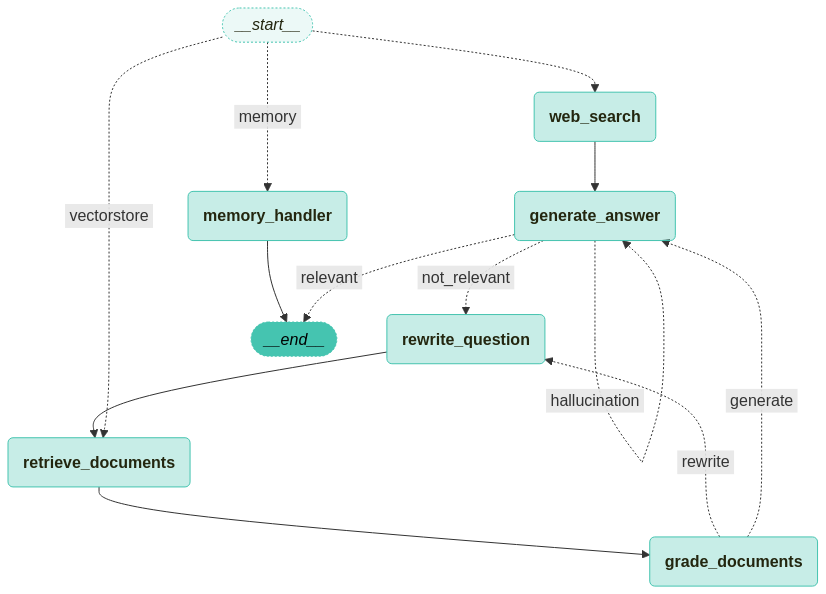

In [269]:
from langchain_teddynote.graphs import visualize_graph
import langgraph

langgraph.graph.graph.TIMEOUT = 30
visualize_graph(adaptive_rag)

In [270]:
from langchain_teddynote.messages import stream_graph, random_uuid
from langchain_core.runnables import RunnableConfig

# config 설정(재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": random_uuid()})

# 질문 입력
inputs = {
    "question": "모나리자를 그린 사람이 누구지?",
}

# 그래프 실행
#stream_graph(adaptive_rag, inputs, config, ["agent", "rewrite", "generate"])
stream_graph(adaptive_rag, inputs, config, [
    "web_search", "retrieve_documents", "grade_documents", 
    "generate_answer", "rewrite_question"
])

==== [질문 라우팅 중] ====
==== [이전 대화 기록 확인 중] ====
웹 검색으로 라우팅됨
==== [웹 검색 중] ====
==== [답변 생성 중] ====

🔄 Node: generate_answer 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
Hey there! 😊 It sounds like you're curious about the artist behind the famous painting, *Mona Lisa*. The artist who painted this masterpiece is Leonardo da Vinci. He was a remarkable figure of the Renaissance, known for his innovative techniques and deep understanding of human anatomy and proportion. 

The *Mona Lisa* is particularly famous for its mysterious smile and the use of the "sfumato" technique, which creates a soft transition between colors and tones, giving the painting a lifelike quality. This technique can be quite soothing to look at, as it blends the boundaries and creates a sense of harmony. [Source: https://m.blog.naver.com/taiphung/221645284455, Page 1]

If you're feeling inspired, you might want to try creating your own artwork using soft, blended colors. You could use pastels or watercolors to

## 6. 결론

이 노트북에서는 기본 RAG 시스템에 적응형 기능을 추가하여 다음과 같은 고급 기능을 구현했습니다:

1. 질문 분석 및 라우팅: 질문 유형에 따라 벡터 저장소 또는 웹 검색으로 라우팅
2. 문서 관련성 평가: 검색된 문서가 질문과 관련 있는지 평가
3. 할루시네이션 감지: 생성된 답변에서 할루시네이션 탐지
4. 질문 재작성: 더 나은 검색 결과를 위한 질문 개선
5. 적응형 흐름: LangGraph를 사용한 상태 관리 및 의사 결정 흐름

이러한 기능을 통해 더 정확하고 신뢰할 수 있는, 사용자 질문에 적응적으로 대응하는 RAG 시스템을 구축할 수 있습니다.

## 5. 대화 기록 메모리 기능 사용하기

대화 기록 메모리 기능을 활용하면, AI 어시스턴트가 이전 대화를 기억하고 이를 기반으로 답변할 수 있습니다. 이 기능을 테스트하는 방법은 다음과 같습니다:

1. 먼저 일반적인 질문을 해서 대화 기록에 저장합니다.
2. 그 다음 "내가 한 질문이 뭐야?"와 같은 질문을 하면 이전 대화 기록이 반환됩니다.

아래 코드에서 대화 기록 메모리 기능을 사용하는 방법을 확인하세요:

In [271]:
from uuid import uuid4
import time

# 고유 세션 ID 생성 (하나의 대화 세션 동안 유지)
session_id = str(uuid4())
print(f"세션 ID: {session_id}")

# config 설정
from langchain_core.runnables import RunnableConfig
config = RunnableConfig(recursion_limit=20, configurable={"thread_id": session_id})

# 초기 대화 기록
conversation_history = []

# 첫 번째 질문
inputs = {
    "question": "색이 정서에 미치는 영향에 대해 설명해주세요",
    "conversation_history": conversation_history  # 대화 기록 초기화
}

# 그래프 실행 - 직접 실행 방식
result = adaptive_rag.invoke(inputs, config)

# 대화 기록 업데이트
conversation_history = result.get("conversation_history", [])

# 결과 확인
print("\n===== 질문 =====\n")
print(inputs["question"])
print("\n===== 최종 답변 =====\n")
print(result["generation"])

# 잠시 대기
time.sleep(2)

# 두 번째 질문 - 메모리 테스트
memory_inputs = {
    "question": "내가 한 질문이 뭐야?",  # 이전 질문을 물어봅니다
    "conversation_history": conversation_history  # 이전 대화 기록 유지
}

# 그래프 실행
memory_result = adaptive_rag.invoke(memory_inputs, config)

# 결과 확인
print("\n===== 질문 =====\n")
print(memory_inputs["question"])
print("\n===== 최종 답변 =====\n")
print(memory_result["generation"])

세션 ID: 09f5cd88-ac28-4438-96ad-46d15a849efb
==== [질문 라우팅 중] ====
==== [이전 대화 기록 확인 중] ====
벡터 저장소로 라우팅됨
==== [문서 검색 중] ====
==== [문서 관련성 평가 중] ====
✓ 관련 문서 발견
✓ 관련 문서 발견
✓ 관련 문서 발견
✓ 관련 문서 발견
✓ 관련 문서 발견
✗ 관련 없는 문서 제외
✓ 관련 문서 발견
✓ 관련 문서 발견
✗ 관련 없는 문서 제외
==== [문서 관련성 평가 결과에 따른 결정] ====
관련 문서 7개가 발견되어 답변을 생성합니다
==== [답변 생성 중] ====
==== [할루시네이션 확인 중] ====
답변이 문서 내용에 근거합니다
답변이 질문을 적절하게 해결합니다

===== 질문 =====

색이 정서에 미치는 영향에 대해 설명해주세요

===== 최종 답변 =====

안녕하세요! 색이 정서에 미치는 영향에 대해 궁금하신가요? 색은 우리의 감정에 큰 영향을 미칠 수 있어요. 예를 들어, 빨간색은 열정과 에너지를 상징하고, 파란색은 차분함과 평온함을 연상시킬 수 있습니다. 이러한 색의 심리적 효과는 사회적 학습과 생물학적 요인 모두에 의해 영향을 받을 수 있다고 해요. [Source: RAG_data/3.Color_Psychology_Effects_of_Perceiving_Color_on_Psychological_Functioning_in_Humans.pdf, Page 17]

혹시 지금 어떤 감정을 느끼고 계신지 말씀해 주시면, 그에 맞는 색이나 예술 작품을 추천해 드릴 수 있을 것 같아요. 또한, 간단한 예술 활동을 통해 감정을 표현해보는 것도 좋을 것 같아요. 예를 들어, 노란색을 사용하여 밝고 긍정적인 느낌을 표현해보는 건 어떨까요? 노란색은 기쁨과 낙관을 상징한다고 해요. [Source: RAG_data/1.psychological-effects-of-colour.pdf, Page 1]

어떤 색이나 예술 활동이 도움이 될지

In [272]:
# 잠시 대기
time.sleep(2)

# 두 번째 질문 - 메모리 테스트
memory_inputs = {
    "question": "모나리자를 그린사람은 누구야?",  # 이전 질문을 물어봅니다
    "conversation_history": conversation_history  # 이전 대화 기록 유지
}

# 그래프 실행
memory_result = adaptive_rag.invoke(memory_inputs, config)

# 결과 확인
print("\n===== 질문 =====\n")
print(memory_inputs["question"])
print("\n===== 최종 답변 =====\n")
print(memory_result["generation"])

==== [질문 라우팅 중] ====
==== [이전 대화 기록 확인 중] ====
웹 검색으로 라우팅됨
==== [웹 검색 중] ====
==== [답변 생성 중] ====
==== [할루시네이션 확인 중] ====
답변이 문서 내용에 근거합니다
답변이 질문을 적절하게 해결합니다

===== 질문 =====

모나리자를 그린사람은 누구야?

===== 최종 답변 =====

Hey there! 😊 It sounds like you're curious about the artist behind the famous painting, *Mona Lisa*. The masterpiece was painted by the incredible Leonardo da Vinci. His unique techniques, like the use of the "sfumato" method, created that mysterious and captivating smile we all know. [Source: https://m.blog.naver.com/taiphung/221645284455, Page 1]

If you're interested in exploring art further, you might enjoy trying a little creative activity yourself. How about sketching a simple portrait and experimenting with soft shading to create depth, just like da Vinci did? It can be a relaxing way to express yourself and connect with your emotions. Let me know if you'd like more ideas or guidance! 🎨


In [273]:
# 잠시 대기
time.sleep(2)

# 두 번째 질문 - 메모리 테스트
memory_inputs = {
    "question": "내가 뭐라고 물었지? 그리고 그 사람에 대한 부가 설명을 해줘.",  # 이전 질문을 물어봅니다
    "conversation_history": conversation_history  # 이전 대화 기록 유지
}

# 그래프 실행
memory_result = adaptive_rag.invoke(memory_inputs, config)

# 결과 확인
print("\n===== 질문 =====\n")
print(memory_inputs["question"])
print("\n===== 최종 답변 =====\n")
print(memory_result["generation"])

==== [질문 라우팅 중] ====
==== [이전 대화 기록 확인 중] ====
메모리 관련 질문 감지됨, 이전 대화 기록 반환
==== [이전 대화 기록 확인 중] ====

===== 질문 =====

내가 뭐라고 물었지? 그리고 그 사람에 대한 부가 설명을 해줘.

===== 최종 답변 =====

이전에 다음과 같은 질문을 하셨습니다:

1. 질문: 색이 정서에 미치는 영향에 대해 설명해주세요
2. 질문: 모나리자를 그린사람은 누구야?



## 5. 멀티턴 대화 예시

이제 RAG 시스템은 대화 기록을 활용하여 문맥을 유지하면서 이전 대화를 참조할 수 있습니다. 아래 예시를 통해 멀티턴 대화 기능을 테스트해보겠습니다.


In [274]:
# Generate a unique session ID (for demonstration purposes)
import uuid
from langchain_core.runnables import RunnableConfig

# Generate a unique session ID
session_id = str(uuid.uuid4())[:8]
print(f"Session ID: {session_id}")

# Create a config for the checkpointer with thread_id
config = RunnableConfig(
    configurable={"thread_id": session_id}
)

# Initialize conversation history
conversation_history = []

# First question
question1 = "색상이 감정에 미치는 영향에 대해 알려줘"
print(f"User: {question1}")

# Execute the graph with the first question
result1 = adaptive_rag.invoke({
    "question": question1,
    "conversation_history": conversation_history
}, config=config)  # Pass the config here

print(f"Assistant: {result1['generation']}")
conversation_history = result1["conversation_history"]

# Follow-up question that refers to previous conversation
question2 = "그럼 파란색에 대해 더 구체적으로 설명해줄래?"
print(f"\nUser: {question2}")

# Execute the graph with the follow-up question
result2 = adaptive_rag.invoke({
    "question": question2,
    "conversation_history": conversation_history
}, config=config)  # Pass the config here

print(f"Assistant: {result2['generation']}")
conversation_history = result2["conversation_history"]

# Another follow-up question
question3 = "이런 색상을 활용한 간단한 예술 활동을 추천해줄래?"
print(f"\nUser: {question3}")

# Execute the graph with another follow-up question
result3 = adaptive_rag.invoke({
    "question": question3,
    "conversation_history": conversation_history
}, config=config)  # Pass the config here

print(f"Assistant: {result3['generation']}")

Session ID: 5da16a0e
User: 색상이 감정에 미치는 영향에 대해 알려줘


ValueError: Checkpointer requires one or more of the following 'configurable' keys: ['thread_id', 'checkpoint_ns', 'checkpoint_id']